# A mesh from Gmsh: heat conduction through a plate with an inclusion

[Gmsh](https://gmsh.info) builds geometries from shapes (rectangles, disks, boolean operations) and meshes them. Its *physical groups* give names and numbers to sides and to regions. `fd.read_gmsh` reads the mesh file, turns the side groups into the boundary markers that `dirichlet=` and `ds` use, and reports the region of every triangle.

We solve the steady heat equation in the plate $(0, 2) \times (0, 1)$ with a circular inclusion of radius $0.25$ at its center, ten times more conductive than the plate,

$$-\nabla\cdot\left(k\,\nabla u\right) = 0, \qquad k = 10 \text{ in the inclusion}, \quad k = 1 \text{ in the plate},$$

with $u = 0$ on the left side, $u = 1$ on the right side, and insulated walls at the top and the bottom, $k\,\partial_n u = 0$. Without the inclusion the solution would be $u = x/2$.

Gmsh is installed with `pip install gmsh`. On Linux it also needs the OpenGL library, for example `sudo apt-get install libglu1-mesa`.

In [1]:
import os
import numpy as np
import matplotlib.pyplot as plt
import gmsh
import femd as fd
from femd import dot, grad, dx, ds

os.makedirs("output", exist_ok=True)

## The geometry and the mesh in Gmsh

A rectangle and a disk. `fragment` cuts the rectangle along the circle, so the two surfaces share the circle and the mesh is conforming across it. We then sort the curves and the surfaces by their bounding boxes and give them physical groups,

| group | dimension | tag |
|---|---|---|
| `left`, `right`, `walls` | 1 (sides) | 1, 2, 3 |
| `plate`, `inclusion` | 2 (regions) | 10, 11 |

and mesh with triangles no larger than $0.05$.

In [2]:
gmsh.initialize()
gmsh.option.setNumber("General.Terminal", 0)
gmsh.model.add("plate")
rectangle = gmsh.model.occ.addRectangle(0, 0, 0, 2, 1)
disk = gmsh.model.occ.addDisk(1, 0.5, 0, 0.25, 0.25)
gmsh.model.occ.fragment([(2, rectangle)], [(2, disk)])
gmsh.model.occ.synchronize()

plate, inclusion = [], []
for dim, tag in gmsh.model.getEntities(2):
    xmin, ymin, zmin, xmax, ymax, zmax = gmsh.model.getBoundingBox(dim, tag)
    if xmax - xmin < 1:
        inclusion.append(tag)
    else:
        plate.append(tag)

left, right, walls = [], [], []
for dim, tag in gmsh.model.getEntities(1):
    xmin, ymin, zmin, xmax, ymax, zmax = gmsh.model.getBoundingBox(dim, tag)
    if xmax < 1e-6:
        left.append(tag)
    elif xmin > 2 - 1e-6:
        right.append(tag)
    elif ymax < 1e-6 or ymin > 1 - 1e-6:
        walls.append(tag)

gmsh.model.addPhysicalGroup(1, left, 1, "left")
gmsh.model.addPhysicalGroup(1, right, 2, "right")
gmsh.model.addPhysicalGroup(1, walls, 3, "walls")
gmsh.model.addPhysicalGroup(2, plate, 10, "plate")
gmsh.model.addPhysicalGroup(2, inclusion, 11, "inclusion")

gmsh.option.setNumber("Mesh.CharacteristicLengthMax", 0.05)
gmsh.model.mesh.generate(2)
gmsh.write("output/plate.msh")
gmsh.finalize()

## Reading the mesh

`fd.read_gmsh` returns a `Mesh2D` (a `QuadMesh` for a mesh of quadrilaterals). `m.report` holds what Gmsh knew: `physical_names`, the side groups by name, which are the boundary markers, `region_names`, the region groups, and `cell_markers`, the region tag of every triangle in the order of the triangles.

1964 triangles
sides:   {'left': 1, 'right': 2, 'walls': 3}
regions: {'plate': 10, 'inclusion': 11}   triangles in the inclusion: 212


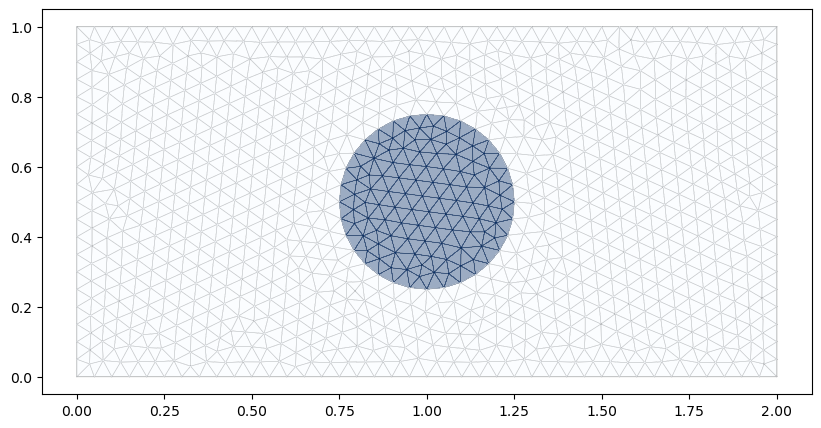

In [3]:
m = fd.read_gmsh("output/plate.msh")
side = m.report["physical_names"]
region = m.report["region_names"]
cells = np.asarray(m.report["cell_markers"])
print(m.ntriangles, "triangles")
print("sides:  ", side)
print("regions:", region, "  triangles in the inclusion:", np.sum(cells == region["inclusion"]))

fig, ax = plt.subplots(figsize=(10, 5))
m.plot(ax)
ax.tripcolor(m.points[:, 0], m.points[:, 1], m.triangles, cells == region["inclusion"], cmap="Blues", alpha=0.4)
ax.set_aspect("equal")
plt.show()

## The conductivity and the solve

The conductivity jumps across the circle, so we make it a piecewise constant function, a Function of the space of constants on each triangle, `fd.DGSpace(m, 0)`, whose coefficients are in the order of the triangles. It takes the value 10 on the triangles of the inclusion and 1 elsewhere, and enters the form like any other function.

The weak form is $(k\,\nabla u, \nabla v) = 0$ for every $v$ that vanishes on the left and right sides. The walls are natural, so nothing is written for them. We use $P_2$ elements, with the values on the two sides built into the space by their names.

In [4]:
D0 = fd.DGSpace(m, 0)
k = fd.Function(D0, "k")
k.vector[:] = np.where(cells == region["inclusion"], 10.0, 1.0)

V = fd.LagrangeSpace(m, 2, dirichlet={side["left"]: 0.0, side["right"]: 1.0})
u, v = fd.TrialFunction(V), fd.TestFunction(V)
uh = fd.solve(k * dot(grad(u), grad(v)) * dx, 0.0 * v * dx)
print(V.dim, "unknowns")

3967 unknowns


**The heat flow.** Heat flows from the hot right side to the cold left side. The heat entering through the right side is $\int k\,\partial_n u\,ds$ over that side, where $k = 1$, computed with `ds` on the side named `right`, and the heat leaving through the left side is $-\int k\,\partial_n u\,ds$ over the left side. In a steady state the two are equal. Without the inclusion both would be $0.5$. The inclusion conducts better, so more heat goes through the plate.

In [5]:
n = fd.FacetNormal()
flux_right = fd.form(dot(grad(uh), n) * ds(side["right"])).assemble()
flux_left = fd.form(dot(grad(uh), n) * ds(side["left"])).assemble()
print(f"heat entering through the right side: {flux_right:.5f}")
print(f"heat leaving through the left side:   {-flux_left:.5f}")

heat entering through the right side: 0.57924
heat leaving through the left side:   0.57924


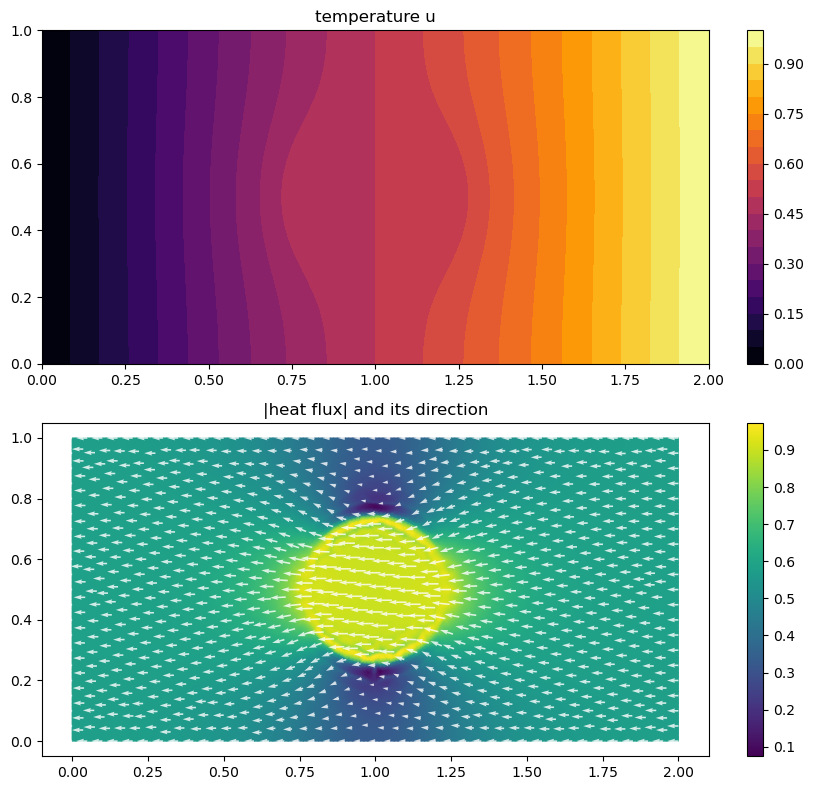

In [10]:
Q = fd.VectorFunctionSpace(m, 2)
q = fd.Function(Q, "heat_flux")
q.vector[:] = Q.project(-k * grad(uh))

fig, axs = plt.subplots(2, 1, figsize=(10, 8))
uh.plot(axs[0], contour=True, levels=21, refine=4, cmap="inferno")
axs[0].set_title("temperature u")
q.plot(axs[1], refine=4, cmap="viridis")
axs[1].set_title("|heat flux| and its direction")
for ax in axs:
    ax.set_aspect("equal")
plt.tight_layout()
plt.show()

The isotherms bend around the inclusion, which is almost at one temperature, and the heat flux is drawn into it.

**For ParaView.** `fd.write_vtk` writes the regions of a Gmsh mesh along with the fields, as the cell array `cell_marker`.

In [7]:
print(fd.write_vtk("output/plate_inclusion.vtu", ("temperature", uh), q))

output/plate_inclusion.vtu
